# Visualise Questionnaire Data

Boxplots, Q-Q plots, sphericity & kruskal tests

In [1]:
import pandas as pd
import numpy as np
from itertools import combinations

import seaborn as sns
import matplotlib.pyplot as plt

from statannotations.Annotator import Annotator
import statannotations as st

from scipy import stats
import scipy.stats as stats
from scipy.stats import kruskal
from scipy.stats import shapiro
from scipy.stats import ttest_rel

from statsmodels.stats.multitest import multipletests
import pingouin as pg


In [2]:
IBM_COLORBLIND = [
    "#ffb000",  # yellow
    "#fe6100",  # orange
    "#dc267f",  # pink
    "#785ef0",  # purple
    "#648fff",  # blue
]
IBM_COLORS = [
    "#6929c4",  # Purple 70
    "#1192e8",  # Cyan 50
    "#005d5d",  # Teal 70
    "#9f1853",  # Magenta 70
    "#fa4d56",  # Red 50
    "#570408",  # Red 90
    "#198038",  # Green 60
    "#002d9c",  # Blue 80
    "#ee538b",  # Magenta 50
    "#b28600",  # Yellow 50
    "#009d9a",  # Teal 50
    "#012749",  # Cyan 90
    "#8a3800",  # Orange 70
    "#a56eff",  # Purple 50
]
IBM_LIGHT = [
    "#8a3ffc",  # Purple 60
    "#33b1ff",  # Cyan 40
    "#007d79",  # Teal 60
    "#ff7eb6",  # Magenta 40
    "#fa4d56",  # Red 50
    "#fff1f1",  # Red 10 (very light)
    "#6fdc8c",  # Green 30
    "#4589ff",  # Blue 50
    "#d12771",  # Magenta 60
    "#d2a106",  # Yellow 40
    "#08bdba",  # Teal 40
    "#bae6ff",  # Cyan 20 (very light)
    "#ba4e00",  # Orange 60
    "#d4bbff",  # Purple 30 (very light)
]


In [3]:
df = pd.read_pickle("../DATA/blocks.pkl")
# block-level df with participant_id, block, route, condition, trust, understanding, nasa


In [4]:
#df.head()


In [5]:
# rename
df['condition'] = df['condition'].replace({
    'Nelo': 'Baseline',
    'Coda': 'Proactive',
    'Lumo': 'Optional'
})

df["block"] = df["block"].astype("category")

plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

CONDITION_LABELS = {
    "Lumo": "Optional",
    "Coda": "Proactive",
    "Nelo": "Baseline",
}

CONDITIONS   = ["Optional", "Proactive", "Baseline"]
DVS          = ["trust", "understanding", "nasa"]
DV_LABELS    = {"trust": "Trust", "understanding": "System Understanding", "nasa": "Mental Workload"}
BLOCKS       = [1, 2, 3]
ALPHA_BONF   = 0.05 / 3
SUBJECT_COL  = "participant_id"

# IBM palette preselection  for the conditions
COLORS = {
    "Lumo": "#6929c4",
    "Coda": "#1192e8",
    "Nelo": "#005d5d",
    "Optional": "#6929c4",
    "Proactive": "#1192e8",
    "Baseline": "#005d5d",
}

In [8]:
def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


def paired_ttests(df, dv, subject_col="participant_id"):
    wide = (
        df.pivot_table(
            index=subject_col,
            columns="condition",
            values=dv,
            aggfunc="mean"
        )
        .dropna(subset=CONDITIONS)
    )

    pairs = list(combinations(CONDITIONS, 2))

    t_values = []
    p_values = []

    for c1, c2 in pairs:
        t, p = stats.ttest_rel(wide[c1], wide[c2])
        t_values.append(t)
        p_values.append(p)

    _, p_adj, _, _ = multipletests(p_values, method="holm") # can change to bonferroni

    results = {}

    for (c1, c2), t, p_raw, p_holm in zip(pairs, t_values, p_values, p_adj):
        results[(c1, c2)] = {
            "t": t,
            "p_raw": p_raw,
            "p_holm": p_holm,
            "sig": sig_stars(p_holm),
            "n": len(wide),
        }

    return results

In [9]:
for dv in ["trust", "understanding", "nasa"]:
    print(f"\n{'='*50}")
    print(f"{dv.upper()}")
    print(f"{'='*50}")

    results = paired_ttests(df, dv)

    for pair, r in results.items():
        print(
            f"{pair[0]} vs {pair[1]}: "
            f"t({r['n']-1}) = {r['t']:.3f}, "
            f"p_raw = {r['p_raw']:.4f}, "
            f"p_holm = {r['p_holm']:.4f}, "
            f"{r['sig']}"
        )


TRUST
Optional vs Proactive: t(28) = 1.938, p_raw = 0.0627, p_holm = 0.1254, ns
Optional vs Baseline: t(28) = 2.614, p_raw = 0.0142, p_holm = 0.0427, *
Proactive vs Baseline: t(28) = 0.611, p_raw = 0.5461, p_holm = 0.5461, ns

UNDERSTANDING
Optional vs Proactive: t(28) = -0.357, p_raw = 0.7237, p_holm = 0.7237, ns
Optional vs Baseline: t(28) = 3.750, p_raw = 0.0008, p_holm = 0.0017, **
Proactive vs Baseline: t(28) = 3.888, p_raw = 0.0006, p_holm = 0.0017, **

NASA
Optional vs Proactive: t(28) = 0.189, p_raw = 0.8511, p_holm = 1.0000, ns
Optional vs Baseline: t(28) = 0.737, p_raw = 0.4670, p_holm = 1.0000, ns
Proactive vs Baseline: t(28) = 0.820, p_raw = 0.4189, p_holm = 1.0000, ns


C:\Users\celin\AppData\Local\Temp\ipykernel_34204\2858616509.py:8: UserWarning: The palette list has more values (14) than needed (3), which may not be intended.
  sns.boxplot(


<Axes: xlabel='condition', ylabel='score'>

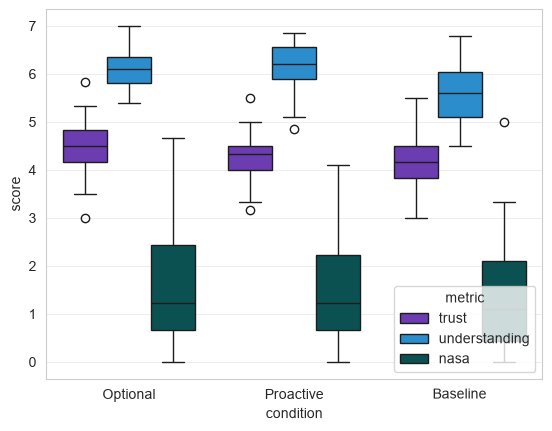

In [10]:
df_long = df.melt(
    id_vars=['condition'],
    value_vars=['trust', 'understanding', 'nasa'],
    var_name='metric',
    value_name='score'
)

sns.boxplot(
    data=df_long,
    x='condition',
    y='score',
    hue='metric',
    palette=IBM_COLORS
)

## Boxplots

In [11]:
def stylised_boxplot(df, metric):
    """
    Parameters
    ----------
    df : pd.DataFrame
    metric : str
        One of {"trust", "understanding", "nasa"}.
    """

    # can change axis labels here! brackets are drawn for the pairs defined; pre-selected sig pairs only
    settings = {
        "trust": {
            "ylabel": "STS-AD Score",
            "pairs": [("Optional", "Baseline")], # sig
            "print_stats": False,
        },
        "understanding": {
            "ylabel": "System Understanding",
            "pairs": [
                ("Optional", "Baseline"), # sig
                ("Proactive", "Baseline")
            ],
            "print_stats": False,
        },
        "nasa": {
            "ylabel": "Mental Workload (NASA-TLX)",
            "pairs": [], # none are sig, so no brackets
            "print_stats": True,
        },
    }

    if metric not in settings:
        raise ValueError(f"metric must be one of {list(settings.keys())}")

    cfg = settings[metric]

    rng = np.random.default_rng(42)
    plt.rcParams["font.sans-serif"] = ["Roboto"]

    fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=300)

    # Boxplot
    sns.boxplot(
        data=df,
        x="condition",
        y=metric,
        hue="condition",
        order=CONDITIONS,
        palette=COLORS,
        width=0.6,
        fliersize=0,
        linewidth=1,
        boxprops=dict(alpha=0.45),
        medianprops=dict(color="#111", linewidth=1),
        whiskerprops=dict(color="#666", linewidth=1),
        capprops=dict(color="#666", linewidth=1),
        ax=ax,
    )


    for i, c in enumerate(CONDITIONS):
        vals = df[df["condition"] == c][metric].dropna().values
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))

        mean_val = vals.mean()
        # this adds the scatterplots to the boxplots
        ax.scatter(
            np.full_like(vals, i) + jitter,
            vals,
            color=COLORS[c],
            s=20,
            alpha=0.5,
            zorder=4,
            linewidths=0,
        )
        # this adds the mean dashed lines
        ax.hlines(
            mean_val,
            i - 0.3,
            i + 0.3,
            colors=COLORS[c], # in the colour of the condition
            linestyles="--",
            linewidth=1,
            zorder=5,
        )

    # to check / print stats
    if cfg["print_stats"]:
        summary = (
            df.groupby("condition")[metric]
            .agg(["mean", "std", "count"])
            .reindex(CONDITIONS)
        )

        print(f"\n{metric.upper()} descriptive statistics:")
        for condition, row in summary.iterrows():
            print(
                f"{condition}: "
                f"M = {row['mean']:.2f}, "
                f"SD = {row['std']:.2f}, "
                f"N = {int(row['count'])}"
            )


    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels(CONDITIONS, fontsize=10, color="black")
    ax.set_xlabel("")
    ax.set_ylabel(cfg["ylabel"], fontsize=12)


    ax.set_facecolor("#FFFFFF")
    ax.grid(axis="y", color="#ddd", linewidth=0.5, linestyle="--")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#ccc")
    ax.spines["bottom"].set_color("#ccc")

    # loop to change the box outlines to their condition colours
    for patch, c in zip(ax.patches, CONDITIONS):
        patch.set_edgecolor(COLORS[c])
        patch.set_linewidth(1.2)

    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    # *** bracket annotations
    if cfg["pairs"]:
        annotator = Annotator(
            ax,
            cfg["pairs"],
            data=df,
            x="condition",
            y=metric,
        )

        annotator.configure(
            test="t-test_paired",
            comparisons_correction="bonferroni", # for some reason 'holm' uses the uncorrected p values
            text_format="star", # "single"
            loc="outside",
        )

        annotator.apply_and_annotate()

    ax.tick_params(
        axis="x",
        which="both",
        length=4,
        width=1,
        color="black",
    )

    ax.tick_params(
        axis="y",
        which="both",
        length=4,
        width=1,
        color="black",
        direction="out",
        labelsize=10,
    )

    plt.xlabel("Explanation Condition", fontsize=12)
    plt.ylabel(cfg["ylabel"], fontsize=12)

    plt.tight_layout()
    plt.show()

In [12]:
print(st.stats.ComparisonsCorrection.methods_names.keys())

dict_keys(['bonferroni', 'bonf', 'Bonferroni', 'holm-bonferroni', 'HB', 'Holm-Bonferroni', 'holm', 'benjamini-hochberg', 'BH', 'fdr_bh', 'Benjamini-Hochberg', 'fdr_by', 'Benjamini-Yekutieli', 'BY'])


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Proactive vs. Baseline: t-test paired samples with Bonferroni correction, P_val:1.132e-03 t=3.888e+00
Optional vs. Baseline: t-test paired samples with Bonferroni correction, P_val:1.637e-03 t=3.750e+00


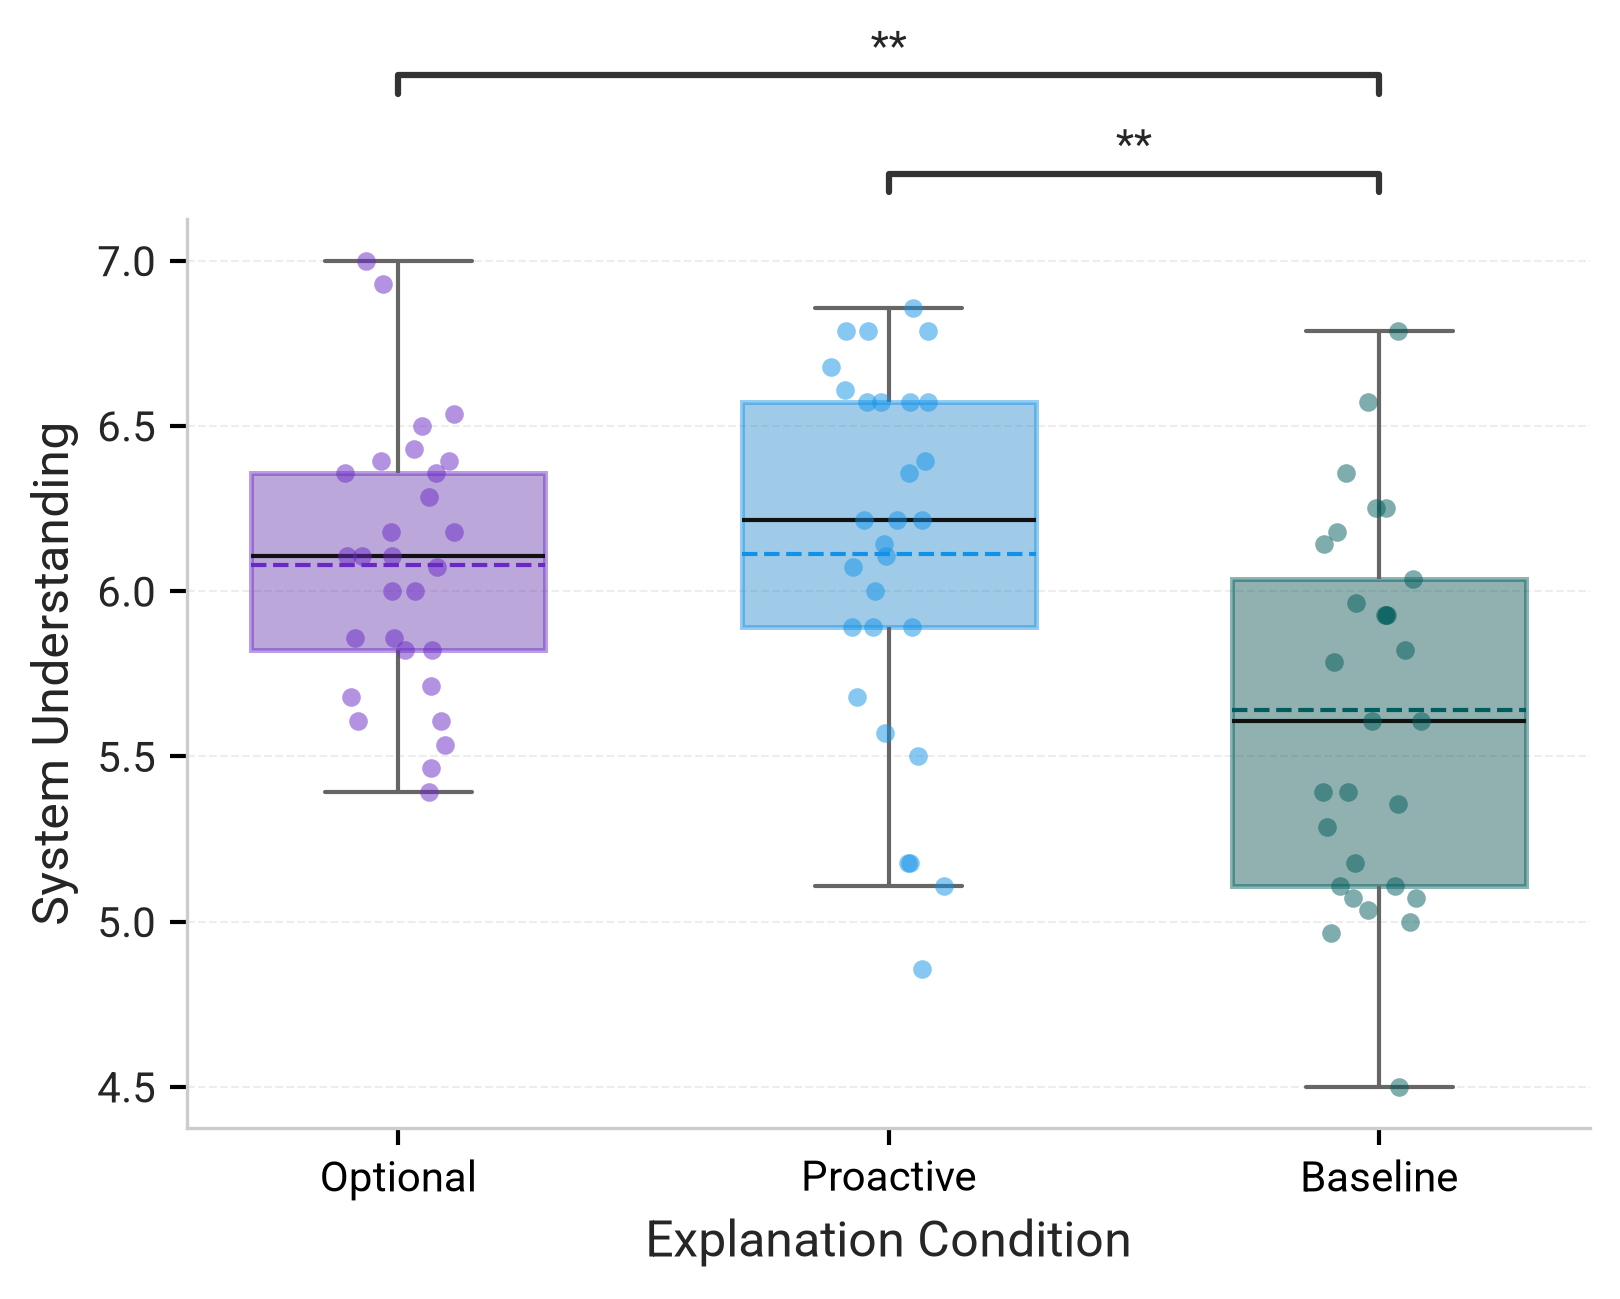

In [13]:
#stylised_boxplot(df, "trust")
#stylised_boxplot(df, "nasa")
stylised_boxplot(df, "understanding")

## EXPLANATION vs NO EXPLANATION

In [14]:
df_grouped = df.copy()

df_grouped["explanation_group"] = df_grouped["condition"].replace({
    "Optional": "Explanation",
    "Proactive": "Explanation",
    "Baseline": "No Explanation"
})

# average within participant + group
summary = (
    df_grouped
    .groupby(["participant_id", "explanation_group"])["trust"]
    .mean()
    .reset_index()
)

# pivot to wide format
pivot = summary.pivot(
    index="participant_id",
    columns="explanation_group",
    values="trust"
)

#paired t-test
t, p = ttest_rel(
    pivot["Explanation"],
    pivot["No Explanation"]
)

print(f"t = {t:.3f}, p = {p:.4f}")


t = 1.858, p = 0.0738


In [15]:
diff = pivot["Explanation"] - pivot["No Explanation"]
cohens_d = diff.mean() / diff.std(ddof=1)

print(cohens_d)


0.3449706678191508


In [16]:
stat, p = shapiro(diff)

print(f"W = {stat:.3f}, p = {p:.4f}")


W = 0.964, p = 0.4029


In [31]:
def stylised_boxplot_grouped(df, metric, group_colors=None):

    GROUP_ORDER = ["No Explanation", "Explanation"]
    if group_colors is None:
        group_colors = {"No Explanation": "#6929c4", "Explanation": "#1192e8"}

    settings = {
        "trust": {"ylabel": "STS-AD Score", "print_stats": True},
        "understanding": {"ylabel": "System Understanding", "print_stats": True},
        "nasa": {"ylabel": "Mental Workload (NASA-TLX)", "print_stats": True},
    }
    if metric not in settings:
        raise ValueError(f"metric must be one of {list(settings.keys())}")
    cfg = settings[metric]

    df_grouped = df.copy()
    df_grouped["explanation_group"] = df_grouped["condition"].replace({
        "Optional": "Explanation",
        "Proactive": "Explanation",
        "Baseline": "No Explanation",
    })

    summary = (df_grouped.groupby(["participant_id", "explanation_group"])[metric].mean().reset_index())

    rng = np.random.default_rng(42)
    plt.rcParams["font.sans-serif"] = ["Roboto"]

    fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=300)

    sns.boxplot(
        data=summary,
        x="explanation_group",
        y=metric,
        hue="explanation_group",
        order=GROUP_ORDER,
        palette=group_colors,
        width=0.5,
        fliersize=0,
        linewidth=1,
        boxprops=dict(alpha=0.45),
        medianprops=dict(color="#111", linewidth=1),
        whiskerprops=dict(color="#666", linewidth=1),
        capprops=dict(color="#666", linewidth=1),
        ax=ax,
        legend=False,
    )

    # scatter + mean dashed lines
    for i, g in enumerate(GROUP_ORDER):
        vals = summary[summary["explanation_group"] == g][metric].dropna().values
        jitter = rng.uniform(-0.1, 0.1, size=len(vals))
        mean_val = vals.mean()

        ax.scatter(
            np.full_like(vals, i) + jitter,
            vals,
            color=group_colors[g],
            s=24,
            alpha=0.5,
            zorder=4,
            linewidths=0,
        )
        ax.hlines(
            mean_val,
            i - 0.25,
            i + 0.25,
            colors=group_colors[g],
            linestyles="--",
            linewidth=1,
            zorder=5,
        )

    if cfg["print_stats"]:
        desc = (
            summary.groupby("explanation_group")[metric]
            .agg(["mean", "std", "count"])
            .reindex(GROUP_ORDER)
        )
        print(f"\n{metric.upper()} descriptive statistics (grouped):")
        for group, row in desc.iterrows():
            print(f"{group}: M = {row['mean']:.2f}, SD = {row['std']:.2f}, N = {int(row['count'])}")

        pivot = summary.pivot(index="participant_id", columns="explanation_group", values=metric)
        t_stat, p_val = ttest_rel(pivot["Explanation"], pivot["No Explanation"])
        print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

    ax.set_xticks(range(len(GROUP_ORDER)))
    ax.set_xticklabels(GROUP_ORDER, fontsize=10, color="black")
    ax.set_xlabel("")
    ax.set_ylabel(cfg["ylabel"], fontsize=12)

    ax.set_facecolor("#FFFFFF")
    ax.grid(axis="y", color="#ddd", linewidth=0.5, linestyle="--")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#ccc")
    ax.spines["bottom"].set_color("#ccc")

    for patch, g in zip(ax.patches, GROUP_ORDER[::-1]): # idk why i have to reverse this
        patch.set_edgecolor(group_colors[g])
        patch.set_linewidth(1.2)

    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    # significance bracket for the single pairwise comparison
    annotator = Annotator(
        ax,
        [("No Explanation", "Explanation")],
        data=summary,
        x="explanation_group",
        y=metric,
        order=GROUP_ORDER,
    )
    annotator.configure(
        test="t-test_paired",
        text_format="star",
        loc="outside",
    )
    annotator.apply_and_annotate()

    ax.tick_params(axis="x", which="both", length=4, width=1, color="black")
    ax.tick_params(axis="y", which="both", length=4, width=1, color="black",direction="out", labelsize=10,)

    plt.xlabel("Explanation Condition", fontsize=12)
    plt.ylabel(cfg["ylabel"], fontsize=12)

    plt.tight_layout()
    plt.show()


In [ ]:
stylised_boxplot_grouped(df, "trust")

##  Q-Q Plots

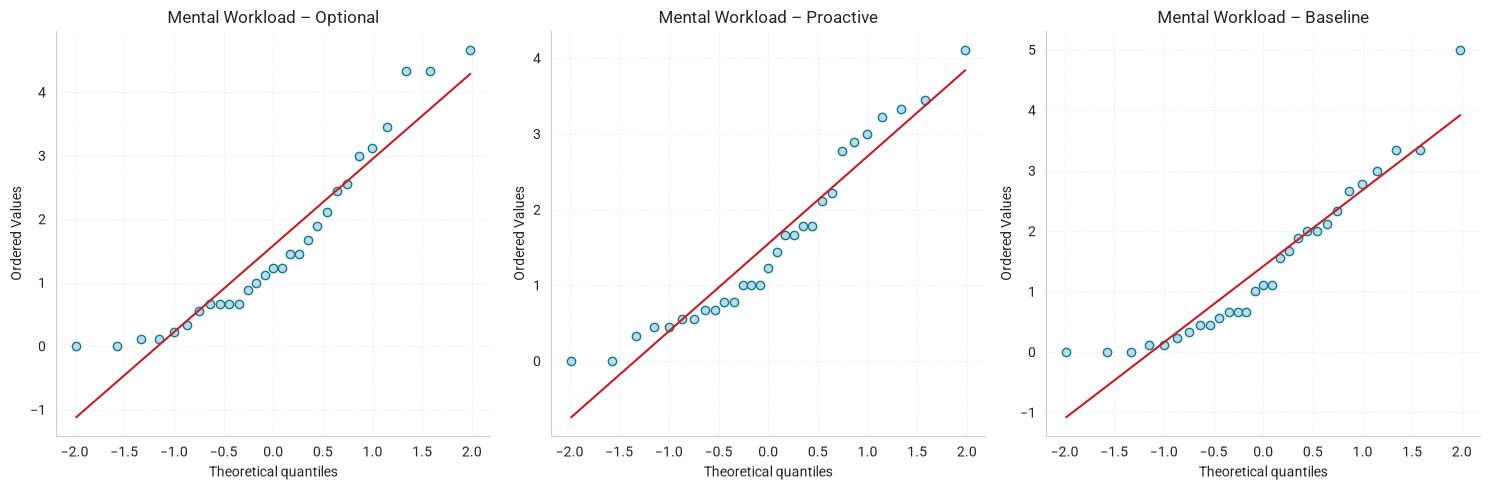

In [17]:
dv = "nasa"
condition_col = "condition"

conditions = df[condition_col].unique()


fig, axes = plt.subplots(1, len(conditions), figsize=(5 * len(conditions), 5))

if len(conditions) == 1:
    axes = [axes]

for ax, cond in zip(axes, conditions):
    subset = df[df[condition_col] == cond][dv].dropna()

    stats.probplot(subset, dist="norm", plot=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#ccc")
    ax.spines["bottom"].set_color("#ccc")
    ax.tick_params(axis='x', which='both', length=4, width=1, color='black')
    ax.tick_params(axis='y', which='both', length=4, width=1, color='black',        direction='out', labelsize=10 )
    ax.set_facecolor("#FFFFFF")
    ax.get_lines()[0].set_markerfacecolor("#BFD7EA")
    ax.get_lines()[0].set_markeredgecolor("#087E8B")
    ax.grid(axis="y", color="#ddd", linewidth=0.5, linestyle="--")
    ax.grid(axis="x", color="#ddd", linewidth=0.5, linestyle="--")
    ax.get_lines()[1].set_color("#C81D25")

    ax.set_title(f"Mental Workload – {cond}")

plt.tight_layout()
plt.show()


In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

res = stats.probplot(df['nasa'], dist="norm", plot=ax)

# res[0][0] = theoretical quantiles
# res[0][1] = ordered values
# res[1][1] = slope, intercept, r
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#ccc")
ax.spines["bottom"].set_color("#ccc")
ax.tick_params(axis='x', which='both', length=4, width=1, color='black')
ax.tick_params(axis='y', which='both', length=4, width=1, color='black',        direction='out', labelsize=10 )
ax.set_facecolor("#FFFFFF")
ax.get_lines()[0].set_markerfacecolor("#BFD7EA")
ax.get_lines()[0].set_markeredgecolor("#087E8B")
ax.grid(axis="y", color="#ddd", linewidth=0.5, linestyle="--")
ax.grid(axis="x", color="#ddd", linewidth=0.5, linestyle="--")
ax.get_lines()[1].set_color("#C81D25")  # reference line (grey)

ax.set_title("Q-Q Plot of Mental Workload")
plt.show()


In [ ]:
for cond in df['condition'].unique():
    stat, p = shapiro(df[df['condition'] == cond]['nasa'])
    print(cond, p)


### kruskal test

In [ ]:
kruskal(
    df[df['condition']=="Baseline"]['nasa'],
    df[df['condition']=="Proactive"]['nasa'],
    df[df['condition']=="Optional"]['nasa']
)


### sphericity tests

In [ ]:
print("Trust:")
print(pg.sphericity(
    data=df,
    dv='trust',
    subject='participant_id',
    within='condition'
))
print("Understanding:")
print(pg.sphericity(
    data=df,
    dv='understanding',
    subject='participant_id',
    within='condition'
))
print("Nasa:")
print(pg.sphericity(
    data=df,
    dv='nasa',
    subject='participant_id',
    within='condition'
))

pg.normality(data=df, dv="trust", method="shapiro",alpha=0.05)
